In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
lam = 5000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y), mechanical system with high damping
def f(t, x):    
    return -lam * x + 0.002 * np.sin(t)
                             
def x_exact(t):
    return np.exp(-5000*t) + 4e-7 * np.sin(t)

Attempting Euler's Forward with h = 0.01...


<ipython-input-19-24e16a9d86fc>:9: RuntimeWarning: overflow encountered in double_scalars
  return -lam * x + 0.002 * np.sin(t)
<ipython-input-22-17a587398f64>:19: RuntimeWarning: invalid value encountered in double_scalars
  x[n+1] = x[n] + h * f(t[n], x[n])


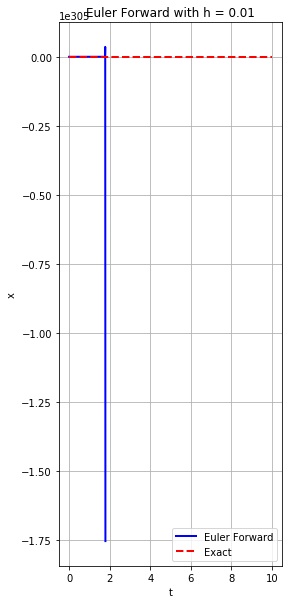

Maximum value reached: nan

Trying with h = 0.0001...


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


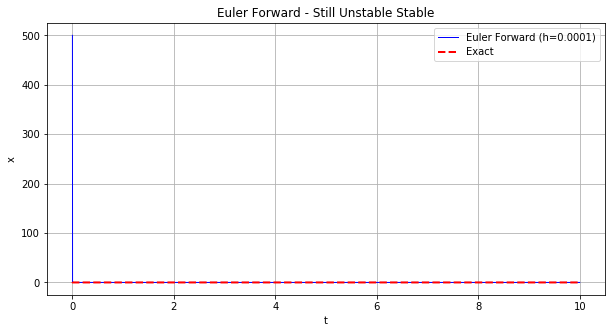

Number of steps needed: 100001
Maximum error: 4.99e+02


In [22]:
def euler_forward(f, x0, t0, t_final, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)

    t[0] = t0
    x[0] = x0

    # Time stepping
    for n in range(num_steps):
        x[n+1] = x[n] + h * f(t[n], x[n])
        t[n+1] = t[n] + h

    return t, x
# Initial condition
x0 = 500.0
t0 = 0.0
t_final = 10.0

# Try Euler's Forward with h = 0.01
h_forward = 0.01
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward)

    # Plot
    plt.figure(figsize=(4, 10))
    plt.plot(t_forward, x_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title(f'Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Maximum value reached: {np.max(np.abs(x_forward)):.2e}")
except:
    print("Solution blew up!")
# Try with MUCH smaller step size
h_forward_stable = 0.0001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward_stable)

plt.figure(figsize=(10, 5))
plt.plot(t_forward, x_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('x')
plt.title('Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(x_forward - x_exact(t_forward))):.2e}")